# Part 3 Unsupervised Machine Learning

This notebook applies K-means clustering to identify common traffic conditions and association-rule mining to discover relationships between time, weather and congestion. The results are interpreted in practical terms for smart-city mobility planning.

In [1]:
import sys
import sklearn

print("Executable:", sys.executable)
print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Executable: /usr/local/bin/python3
Python: 3.13.7 (v3.13.7:bcee1c32211, Aug 14 2025, 19:10:51) [Clang 16.0.0 (clang-1600.0.26.6)]
scikit-learn: 1.9.1


In [2]:
from pathlib import Path
import logging

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "models").exists():
    PROJECT_ROOT = Path.cwd()

DATA_PATH = (
    PROJECT_ROOT.parent
    / "part2_python"
    / "data"
    / "processed"
    / "traffic_features.csv"
)

MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
LOG_PATH = PROJECT_ROOT / "part3.log"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

LOGGER = logging.getLogger(__name__)

if not LOGGER.handlers:
    LOGGER.setLevel(logging.INFO)

    formatter = logging.Formatter(
        "%(asctime)s | %(levelname)s | %(name)s | %(message)s"
    )

    console_handler = logging.StreamHandler()
    console_handler.setFormatter(formatter)

    file_handler = logging.FileHandler(
        LOG_PATH,
        mode="a",
        encoding="utf-8",
    )
    file_handler.setFormatter(formatter)

    LOGGER.addHandler(console_handler)
    LOGGER.addHandler(file_handler)

LOGGER.info("Unsupervised-learning notebook started")

2026-09-25 01:56:17,664 | INFO | __main__ | Unsupervised-learning notebook started


In [3]:
try:
    data = pd.read_csv(DATA_PATH)
except FileNotFoundError as exc:
    LOGGER.error("Feature dataset not found at %s", DATA_PATH)
    raise FileNotFoundError(
        f"Feature dataset not found at {DATA_PATH}. "
        "Run the Part 2 pipeline and feature-engineering script first."
    ) from exc

LOGGER.info(
    "Loaded feature dataset with %d rows and %d columns",
    data.shape[0],
    data.shape[1],
)

print(f"Dataset shape: {data.shape}")
data.head()

2026-09-25 01:56:17,830 | INFO | __main__ | Loaded feature dataset with 48187 rows and 34 columns


Dataset shape: (48187, 34)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_description,date_time,traffic_volume,hour,day_of_week,...,weather_main_Clouds,weather_main_Drizzle,weather_main_Fog,weather_main_Haze,weather_main_Mist,weather_main_Rain,weather_main_Smoke,weather_main_Snow,weather_main_Squall,weather_main_Thunderstorm
0,No Holiday,288.28,0.0,0.0,40,scattered clouds,2012-10-02 09:00:00,5545,9,1,...,1,0,0,0,0,0,0,0,0,0
1,No Holiday,289.36,0.0,0.0,75,broken clouds,2012-10-02 10:00:00,4516,10,1,...,1,0,0,0,0,0,0,0,0,0
2,No Holiday,289.58,0.0,0.0,90,overcast clouds,2012-10-02 11:00:00,4767,11,1,...,1,0,0,0,0,0,0,0,0,0
3,No Holiday,290.13,0.0,0.0,90,overcast clouds,2012-10-02 12:00:00,5026,12,1,...,1,0,0,0,0,0,0,0,0,0
4,No Holiday,291.14,0.0,0.0,75,broken clouds,2012-10-02 13:00:00,4918,13,1,...,1,0,0,0,0,0,0,0,0,0


## K-means clustering

K-means clustering is used to group records with similar traffic, time and weather conditions. The variables are standardised so that variables measured on larger numerical scales do not dominate the clustering process.

In [4]:
risky_weather_columns = [
    "weather_main_Thunderstorm",
    "weather_main_Snow",
    "weather_main_Squall",
    "weather_main_Fog",
    "weather_main_Mist",
    "weather_main_Haze",
    "weather_main_Smoke",
]

available_risky_columns = [
    column
    for column in risky_weather_columns
    if column in data.columns
]

cluster_data = data.copy()

cluster_data["adverse_weather"] = (
    cluster_data[available_risky_columns]
    .max(axis=1)
    .astype(int)
)

clustering_features = [
    "hour_sin",
    "hour_cos",
    "traffic_volume",
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "adverse_weather",
]

X_clustering = cluster_data[clustering_features].copy()

missing_values = int(X_clustering.isna().sum().sum())

if missing_values:
    LOGGER.warning(
        "Imputing %d missing clustering values using column medians",
        missing_values,
    )
    X_clustering = X_clustering.fillna(X_clustering.median())

scaler = StandardScaler()
X_clustering_scaled = scaler.fit_transform(X_clustering)

LOGGER.info(
    "Prepared %d records using %d clustering features",
    X_clustering.shape[0],
    X_clustering.shape[1],
)

print("Clustering features:")
print(clustering_features)
print(f"\nClustering dataset shape: {X_clustering.shape}")

2026-09-25 01:56:17,879 | INFO | __main__ | Prepared 48187 records using 8 clustering features


Clustering features:
['hour_sin', 'hour_cos', 'traffic_volume', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'adverse_weather']

Clustering dataset shape: (48187, 8)


In [5]:
cluster_evaluation = []

for number_of_clusters in range(2, 7):
    model = KMeans(
        n_clusters=number_of_clusters,
        random_state=42,
        n_init=10,
    )

    cluster_labels = model.fit_predict(X_clustering_scaled)

    silhouette = silhouette_score(
        X_clustering_scaled,
        cluster_labels,
        sample_size=10000,
        random_state=42,
    )

    cluster_evaluation.append(
        {
            "Clusters": number_of_clusters,
            "Inertia": model.inertia_,
            "Silhouette_Score": silhouette,
        }
    )

    LOGGER.info(
        "Evaluated K-means with %d clusters: silhouette score %.4f",
        number_of_clusters,
        silhouette,
    )

cluster_evaluation_df = pd.DataFrame(cluster_evaluation)
cluster_evaluation_df.round(4)

2026-09-25 01:56:18,920 | INFO | __main__ | Evaluated K-means with 2 clusters: silhouette score 0.2405
2026-09-25 01:56:19,731 | INFO | __main__ | Evaluated K-means with 3 clusters: silhouette score 0.2409
2026-09-25 01:56:20,540 | INFO | __main__ | Evaluated K-means with 4 clusters: silhouette score 0.2477
2026-09-25 01:56:21,385 | INFO | __main__ | Evaluated K-means with 5 clusters: silhouette score 0.2579
2026-09-25 01:56:22,187 | INFO | __main__ | Evaluated K-means with 6 clusters: silhouette score 0.2170


,Clusters,Inertia,Silhouette_Score
0,2,312106.0163,0.2405
1,3,272706.2610,0.2409
2,4,236160.3323,0.2477
3,5,206780.0821,0.2579
4,6,186141.4886,0.2170


### Selecting the number of clusters

Five clusters produced the highest silhouette score of 0.2579 among the tested values from two to six clusters. Therefore, five clusters were selected for the final K-means model. The modest silhouette score indicates that the groups provide useful segmentation, although traffic conditions overlap rather than forming completely distinct categories.

In [15]:
selected_clusters = int(
    cluster_evaluation_df.loc[
        cluster_evaluation_df["Silhouette_Score"].idxmax(),
        "Clusters",
    ]
)

kmeans_model = KMeans(
    n_clusters=selected_clusters,
    random_state=42,
    n_init=10,
)

cluster_data["cluster"] = kmeans_model.fit_predict(
    X_clustering_scaled
)

LOGGER.info(
    "Trained final K-means model with %d clusters",
    selected_clusters,
)

print(f"Selected number of clusters: {selected_clusters}")
print("Cluster sizes:")
print(cluster_data["cluster"].value_counts().sort_index())

2026-09-25 02:44:25,176 | INFO | __main__ | Trained final K-means model with 5 clusters


Selected number of clusters: 5
Cluster sizes:
cluster
0    17129
1    19520
2    11187
3      331
4       20
Name: count, dtype: int64


In [16]:
cluster_profiles = (
    cluster_data.groupby("cluster")
    .agg(
        records=("cluster", "size"),
        average_hour=("hour", "mean"),
        average_traffic=("traffic_volume", "mean"),
        average_temperature=("temp", "mean"),
        average_rainfall=("rain_1h", "mean"),
        average_snowfall=("snow_1h", "mean"),
        average_cloud_cover=("clouds_all", "mean"),
        adverse_weather_rate=("adverse_weather", "mean"),
        weekend_rate=("is_weekend", "mean"),
    )
    .reset_index()
)

cluster_profiles["record_percentage"] = (
    cluster_profiles["records"]
    / len(cluster_data)
    * 100
)

cluster_profiles.round(2)

,cluster,records,average_hour,average_traffic,average_temperature,average_rainfall,average_snowfall,average_cloud_cover,adverse_weather_rate,weekend_rate,record_percentage
0,0,17129,10.31,1475.58,280.51,0.05,0.00,36.98,0.04,0.33,35.55
1,1,19520,12.90,4900.96,284.45,0.06,0.00,46.67,0.00,0.25,40.51
2,2,11187,10.45,3140.93,276.55,0.10,0.00,72.17,1.00,0.27,23.22
3,3,331,10.78,2774.79,291.79,9.61,0.00,76.32,0.57,0.35,0.69
4,4,20,16.55,3654.75,271.64,0.20,0.36,90.00,0.90,0.05,0.04


In [17]:
cluster_names = {
    0: "Low-demand normal-weather traffic",
    1: "High-demand normal-weather traffic",
    2: "Adverse-weather moderate-demand traffic",
    3: "Rare heavy-rain traffic",
    4: "Rare cold-and-snow traffic",
}

cluster_data["cluster_name"] = cluster_data["cluster"].map(
    cluster_names
)

cluster_profiles["cluster_name"] = cluster_profiles["cluster"].map(
    cluster_names
)

cluster_profiles[
    [
        "cluster",
        "cluster_name",
        "records",
        "record_percentage",
        "average_traffic",
        "average_temperature",
        "average_rainfall",
        "average_snowfall",
        "average_cloud_cover",
        "adverse_weather_rate",
        "weekend_rate",
    ]
].round(2)

,cluster,cluster_name,records,record_percentage,average_traffic,average_temperature,average_rainfall,average_snowfall,average_cloud_cover,adverse_weather_rate,weekend_rate
0,0,Low-demand normal-weather traffic,17129,35.55,1475.58,280.51,0.05,0.00,36.98,0.04,0.33
1,1,High-demand normal-weather traffic,19520,40.51,4900.96,284.45,0.06,0.00,46.67,0.00,0.25
2,2,Adverse-weather moderate-demand traffic,11187,23.22,3140.93,276.55,0.10,0.00,72.17,1.00,0.27
3,3,Rare heavy-rain traffic,331,0.69,2774.79,291.79,9.61,0.00,76.32,0.57,0.35
4,4,Rare cold-and-snow traffic,20,0.04,3654.75,271.64,0.20,0.36,90.00,0.90,0.05


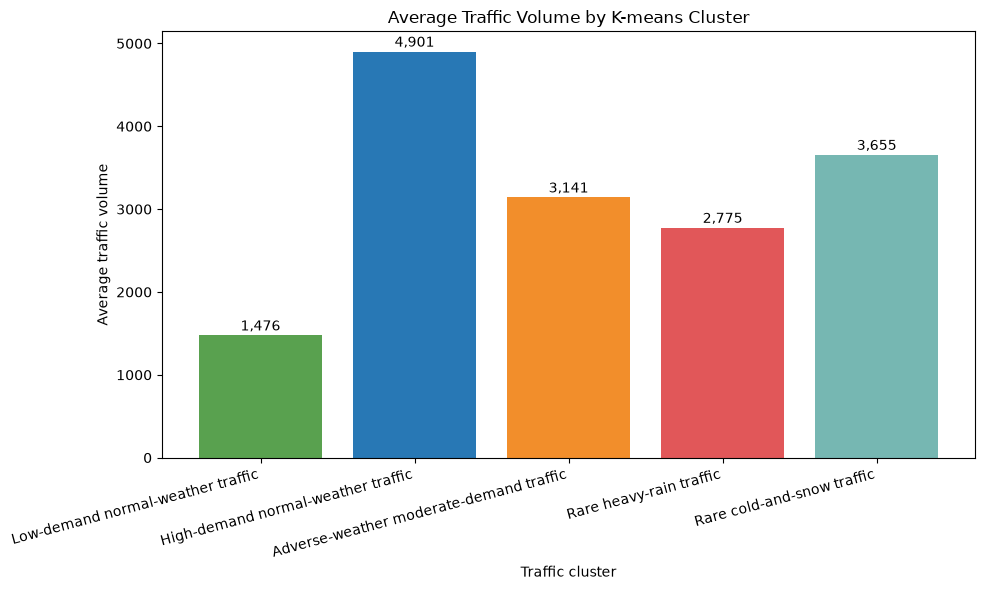

2026-09-25 02:47:16,631 | INFO | __main__ | Saved K-means cluster figure to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/kmeans_cluster_traffic.png


In [19]:
cluster_plot_path = REPORTS_DIR / "kmeans_cluster_traffic.png"

plot_data = cluster_profiles.sort_values("cluster")

plt.figure(figsize=(10, 6))

bars = plt.bar(
    plot_data["cluster_name"],
    plot_data["average_traffic"],
    color=[
    "#59A14F",
    "#2878B5",
    "#F28E2B",
    "#E15759",
    "#76B7B2",
],
)

plt.title("Average Traffic Volume by K-means Cluster")
plt.xlabel("Traffic cluster")
plt.ylabel("Average traffic volume")
plt.xticks(rotation=15, ha="right")

for bar, value in zip(bars, plot_data["average_traffic"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 60,
        f"{value:,.0f}",
        ha="center",
    )

plt.tight_layout()
plt.savefig(cluster_plot_path, dpi=300, bbox_inches="tight")
plt.show()

LOGGER.info("Saved K-means cluster figure to %s", cluster_plot_path)

In [20]:
cluster_profile_path = REPORTS_DIR / "kmeans_cluster_profiles.csv"
cluster_assignment_path = REPORTS_DIR / "traffic_cluster_assignments.csv"
cluster_model_path = MODELS_DIR / "kmeans_traffic_clusters.joblib"

cluster_profiles.to_csv(cluster_profile_path, index=False)

cluster_data[
    [
        "date_time",
        "traffic_volume",
        "cluster",
        "cluster_name",
    ]
].to_csv(cluster_assignment_path, index=False)

joblib.dump(
    {
        "model": kmeans_model,
        "scaler": scaler,
        "features": clustering_features,
        "cluster_names": cluster_names,
    },
    cluster_model_path,
)

LOGGER.info("Saved K-means profiles to %s", cluster_profile_path)
LOGGER.info("Saved traffic cluster assignments to %s", cluster_assignment_path)
LOGGER.info("Saved K-means model to %s", cluster_model_path)

print(f"Saved cluster profiles: {cluster_profile_path}")
print(f"Saved cluster assignments: {cluster_assignment_path}")
print(f"Saved K-means model: {cluster_model_path}")

2026-09-25 02:48:42,702 | INFO | __main__ | Saved K-means profiles to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/kmeans_cluster_profiles.csv
2026-09-25 02:48:42,703 | INFO | __main__ | Saved traffic cluster assignments to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/traffic_cluster_assignments.csv
2026-09-25 02:48:42,704 | INFO | __main__ | Saved K-means model to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/kmeans_traffic_clusters.joblib


Saved cluster profiles: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/kmeans_cluster_profiles.csv
Saved cluster assignments: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/traffic_cluster_assignments.csv
Saved K-means model: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/models/kmeans_traffic_clusters.joblib


### K-means interpretation

The five-cluster solution produced the highest silhouette score of 0.2579 among the tested values. The three largest clusters represented low-demand normal-weather traffic, high-demand normal-weather traffic and adverse-weather moderate-demand traffic. Together, the three largest clusters accounted for 47,836 of 48,187 observations, or approximately 99.27%, while the two rare-weather clusters accounted for the remaining 351 observations, or approximately 0.73%.

The high-demand normal-weather cluster contained 19,520 records and had an average traffic volume of approximately 4,901 vehicles per hour. The low-demand normal-weather cluster contained 17,129 records and averaged approximately 1,476 vehicles per hour. The adverse-weather moderate-demand cluster contained 11,187 records, had an adverse-weather rate of 100% and averaged approximately 3,141 vehicles per hour.

Two much smaller clusters captured rare weather conditions. One contained 331 records characterised by unusually heavy rainfall, while the other contained 20 cold and snowy observations. These groups should be interpreted cautiously because their small sizes limit generalisability.

Overall, the results indicate that traffic demand is strongly differentiated by recurring demand patterns, while adverse and extreme weather conditions form additional operationally relevant groups. The modest silhouette score also indicates that real traffic conditions overlap and do not form completely distinct categories.

## Association-rule mining

Association-rule mining is used to identify combinations of time, weekday type and weather conditions associated with different congestion levels. Rules are evaluated using support, confidence and lift. Lift values above 1 indicate that the consequent occurs more frequently with the antecedent than expected by chance.

In [21]:
association_data = data.copy()

association_data["time_period"] = pd.cut(
    association_data["hour"],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    right=False,
    include_lowest=True,
)

association_data["day_type"] = association_data["is_weekend"].map(
    {
        0: "Weekday",
        1: "Weekend",
    }
)

weather_columns = [
    column
    for column in association_data.columns
    if column.startswith("weather_main_")
]

association_data["weather_condition"] = (
    association_data[weather_columns]
    .idxmax(axis=1)
    .str.replace("weather_main_", "", regex=False)
)

transaction_categories = association_data[
    [
        "time_period",
        "day_type",
        "weather_condition",
        "congestion_quartile",
    ]
].copy()

transaction_categories.columns = [
    "Time",
    "Day",
    "Weather",
    "Congestion",
]

transaction_data = pd.get_dummies(
    transaction_categories.astype(str),
    prefix_sep="=",
    dtype=bool,
)

LOGGER.info(
    "Prepared %d transactions with %d categorical items",
    transaction_data.shape[0],
    transaction_data.shape[1],
)

print(f"Transaction matrix shape: {transaction_data.shape}")
transaction_data.head()

2026-09-25 02:49:00,900 | INFO | __main__ | Prepared 48187 transactions with 21 categorical items


Transaction matrix shape: (48187, 21)


,Time=Afternoon,Time=Evening,Time=Morning,Time=Night,Day=Weekday,Day=Weekend,Weather=Clear,Weather=Clouds,Weather=Drizzle,Weather=Fog,...,Weather=Mist,Weather=Rain,Weather=Smoke,Weather=Snow,Weather=Squall,Weather=Thunderstorm,Congestion=High,Congestion=Low,Congestion=Medium,Congestion=Severe
0,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
1,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
2,False,False,True,False,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,True,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
4,True,False,False,False,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


In [22]:
frequent_itemsets = apriori(
    transaction_data,
    min_support=0.02,
    use_colnames=True,
)

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0,
)

congestion_rules = rules[
    rules["consequents"].apply(
        lambda items: any(
            str(item).startswith("Congestion=")
            for item in items
        )
    )
].copy()

congestion_rules = rules[
    rules["consequents"].apply(
        lambda items: len(items) == 1
        and next(iter(items)).startswith("Congestion=")
    )
    & rules["antecedents"].apply(
        lambda items: not any(
            str(item).startswith("Congestion=") for item in items
        )
    )
].sort_values(
    by=["lift", "confidence", "support"],
    ascending=False,
).reset_index(drop=True)

LOGGER.info(
    "Generated %d frequent itemsets and %d congestion-only rules",
    len(frequent_itemsets),
    len(congestion_rules),
)

print(f"Frequent itemsets: {len(frequent_itemsets)}")
print(f"Congestion-only rules: {len(congestion_rules)}")


2026-09-25 02:49:36,183 | INFO | __main__ | Generated 162 frequent itemsets and 66 congestion-only rules


Frequent itemsets: 162
Congestion-only rules: 66


In [23]:
def format_items(items):
    return ", ".join(sorted(str(item) for item in items))


top_rules = congestion_rules.head(10).copy()

top_rules["Antecedent"] = top_rules["antecedents"].apply(
    format_items
)

top_rules["Consequent"] = top_rules["consequents"].apply(
    format_items
)

top_rules_display = top_rules[
    [
        "Antecedent",
        "Consequent",
        "support",
        "confidence",
        "lift",
    ]
].copy()

top_rules_display.round(4)

,Antecedent,Consequent,support,confidence,lift
0,"Day=Weekend, Time=Night",Congestion=Low,0.0644,0.8861,3.5443
1,"Day=Weekend, Time=Night, Weather=Clear",Congestion=Low,0.0220,0.8631,3.4523
2,"Time=Night, Weather=Clouds",Congestion=Low,0.0492,0.8526,3.4104
3,"Time=Night, Weather=Clear",Congestion=Low,0.0696,0.8512,3.4049
4,Time=Night,Congestion=Low,0.2163,0.8488,3.3951
5,"Day=Weekend, Time=Afternoon, Weather=Clouds",Congestion=High,0.0243,0.8472,3.3868
6,"Day=Weekday, Time=Night, Weather=Clear",Congestion=Low,0.0476,0.8459,3.3834
7,"Time=Night, Weather=Rain",Congestion=Low,0.0243,0.8456,3.3823
8,"Day=Weekday, Time=Night, Weather=Clouds",Congestion=Low,0.0355,0.8410,3.3641
9,"Time=Night, Weather=Mist",Congestion=Low,0.0351,0.8366,3.3461


In [24]:
all_rules_to_save = congestion_rules.copy()
all_rules_to_save["antecedents"] = all_rules_to_save[
    "antecedents"
].apply(format_items)
all_rules_to_save["consequents"] = all_rules_to_save[
    "consequents"
].apply(format_items)

association_rules_path = REPORTS_DIR / "association_rules.csv"
top_rules_path = REPORTS_DIR / "top_association_rules.csv"

all_rules_to_save.to_csv(association_rules_path, index=False)
top_rules_display.to_csv(top_rules_path, index=False)

LOGGER.info(
    "Saved congestion association rules to %s",
    association_rules_path,
)
LOGGER.info(
    "Saved top association rules to %s",
    top_rules_path,
)

print(f"Saved all congestion rules: {association_rules_path}")
print(f"Saved top rules: {top_rules_path}")

2026-09-25 02:50:26,583 | INFO | __main__ | Saved congestion association rules to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/association_rules.csv
2026-09-25 02:50:26,586 | INFO | __main__ | Saved top association rules to /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/top_association_rules.csv


Saved all congestion rules: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/association_rules.csv
Saved top rules: /Users/misatoniwa/Downloads/smart-city-traffic-capstone/part3_machine_learning/reports/top_association_rules.csv


## Association-rule interpretation

The association-rule analysis identified time of day as the clearest predictor of congestion level. Weekend nights predicted low congestion with 88.61% confidence and a lift of 3.54, meaning that low congestion occurred approximately 3.54 times more frequently under these conditions than would be expected without considering the rule. Night-time alone also predicted low congestion with 84.88% confidence and applied to 21.63% of all observations.

Similar night-time patterns appeared under clear, cloudy, rainy and misty weather conditions. This indicates that the low-traffic pattern was primarily associated with travel timing rather than one particular weather category. In contrast, cloudy weekend afternoons predicted high congestion with 84.72% confidence and a lift of 3.39.

These findings reinforce the earlier conclusion that recurring travel patterns and time of day are stronger operational indicators of traffic demand than weather alone. Smart-city traffic management could use these patterns to reduce unnecessary interventions during predictably quiet night-time periods and prioritise monitoring during higher-congestion afternoon periods.